# aule — Pure time series (series family)

This notebook covers the `axes` parameter that unlocks aule's **series family** of input shapes: `(T,)`, `(C,)`, `(B,T)`, `(C,T)`, `(B,C,T)`. These have no spatial extent and are promoted internally to `(B,1,1,C,T)`, making every generic metric available without reshaping manually.

In [1]:
!pip install -q aule

## Series shapes and the `axes` parameter

In [2]:
import numpy as np
from aule._shapes import to_canonical

shapes = [
    (np.random.randn(100),          't'),
    (np.random.randn(5),            'c'),
    (np.random.randn(8, 100),       'bt'),
    (np.random.randn(5, 100),       'ct'),
    (np.random.randn(8, 5, 100),    'bct'),
]

for arr, ax in shapes:
    c = to_canonical(arr, axes=ax)
    print(f'  axes={ax!r:5}  input={str(arr.shape):15}  canonical={c.shape}')

  axes='t'    input=(100,)           canonical=(1, 1, 1, 1, 100)
  axes='c'    input=(5,)             canonical=(1, 1, 1, 5, 1)
  axes='bt'   input=(8, 100)         canonical=(8, 1, 1, 1, 100)
  axes='ct'   input=(5, 100)         canonical=(1, 1, 1, 5, 100)
  axes='bct'  input=(8, 5, 100)      canonical=(8, 1, 1, 5, 100)


## Generic metrics work transparently on series

In [3]:
from aule.metrics import rmse, mae, pearson_r, wasserstein_distance

gt   = np.random.randn(4, 3, 200)
pred = gt + 0.1 * np.random.randn(*gt.shape)

print('rmse  :', rmse(gt, pred, axes='bct'))
print('mae   :', mae(gt, pred, axes='bct'))
print('r     :', pearson_r(gt, pred, axes='bct'))
print('wass  :', wasserstein_distance(gt, pred, axes='bct'))

rmse  : 0.10092828649967191
mae   : 0.08115917996195333
r     : 0.9950152989019264
wass  : 0.011399874305555684


## Lag correlation — detecting temporal shifts

peak lag: 5 (expected +5)


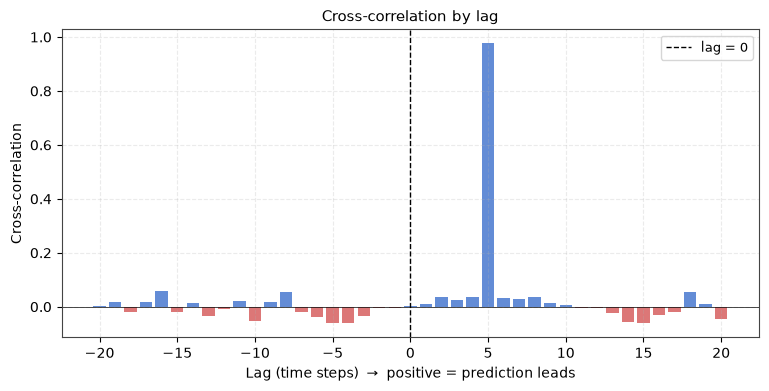

In [4]:
from aule.metrics import lag_correlation
from aule.plots  import plot_lag_correlation

# simulate a prediction that leads the truth by 5 steps
gt_shift   = np.random.randn(4, 2, 200)
pred_shift = np.roll(gt_shift, shift=5, axis=-1)

corr = lag_correlation(gt_shift, pred_shift, max_lag=20, axes='bct')
lags = np.arange(-20, 21)
print('peak lag:', lags[np.argmax(corr)], '(expected +5)')

fig, ax = plot_lag_correlation(gt_shift, pred_shift, max_lag=20, axes='bct')

## DTW distance — shape similarity despite temporal deformation

DTW distance (freq-stretched): 9.85608081600051
DTW distance (identical):      0.0


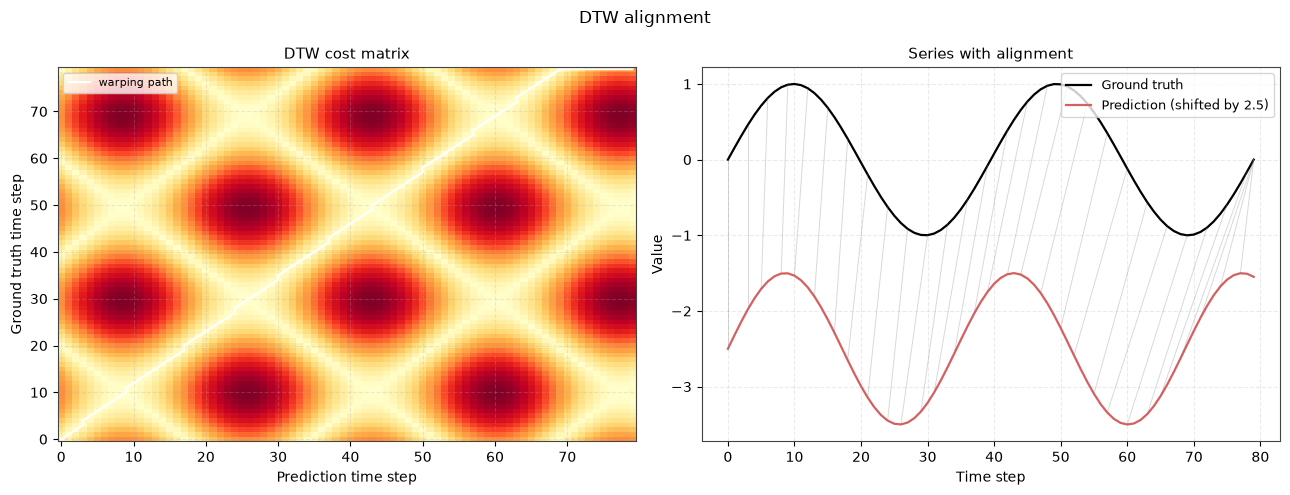

In [5]:
from aule.metrics import dtw_distance
from aule.plots  import plot_dtw_alignment

t = np.linspace(0, 4*np.pi, 80)
gt_dtw   = np.sin(t).reshape(1, 1, 80)
pred_dtw = np.sin(t * 1.15).reshape(1, 1, 80)  # slightly different frequency

print('DTW distance (freq-stretched):', dtw_distance(gt_dtw, pred_dtw, axes='bct'))
print('DTW distance (identical):     ', dtw_distance(gt_dtw, gt_dtw, axes='bct'))

fig, axs = plot_dtw_alignment(gt_dtw, pred_dtw, axes='bct')

## Multi-channel visualisation

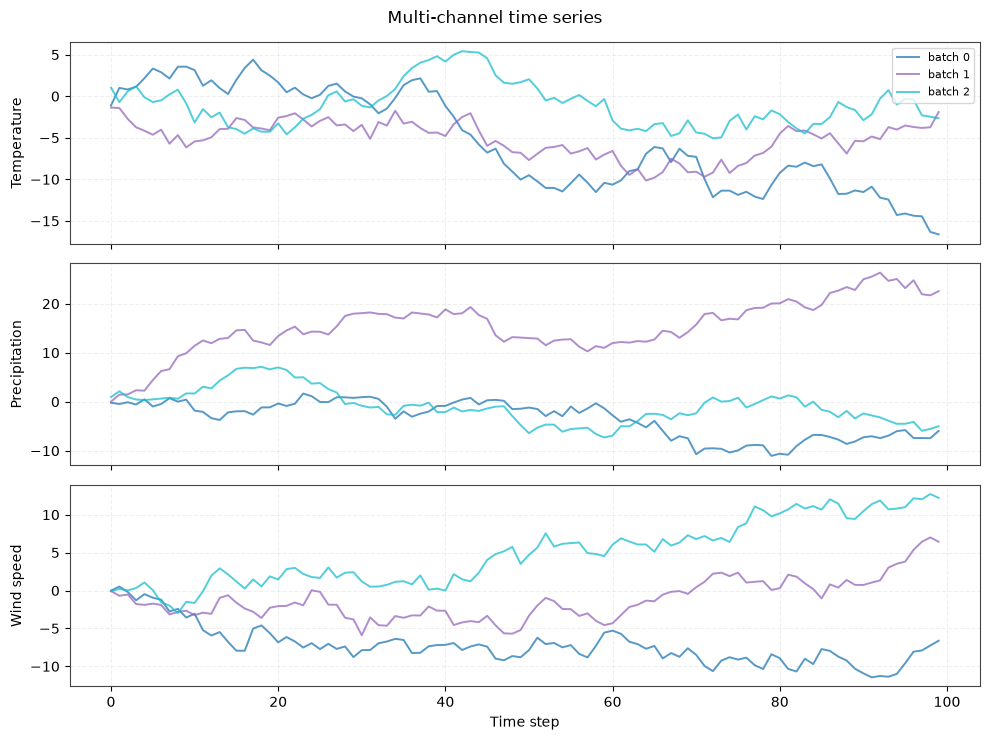

In [6]:
from aule.plots import plot_multi_channel_series

data = np.cumsum(np.random.randn(4, 3, 100), axis=-1)
fig, axs = plot_multi_channel_series(
    data, axes='bct',
    channel_names=['Temperature', 'Precipitation', 'Wind speed'],
    max_batch=3,
)

## Inter-channel correlation matrix

correlation matrix:
[[ 1.   -1.   -0.02]
 [-1.    1.    0.02]
 [-0.02  0.02  1.  ]]


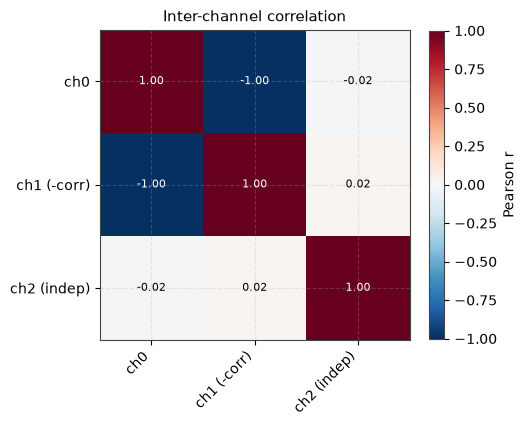

In [7]:
from aule.metrics import cross_channel_correlation
from aule.plots  import plot_channel_correlation_matrix

# three channels with known structure: ch0 and ch1 anti-correlated, ch2 independent
base  = np.random.randn(8, 1, 200)
ch0   = base
ch1   = -base + 0.1 * np.random.randn(8, 1, 200)
ch2   = np.random.randn(8, 1, 200)
data_corr = np.concatenate([ch0, ch1, ch2], axis=1)

corr = cross_channel_correlation(data_corr, axes='bct')
print('correlation matrix:')
print(np.round(corr, 2))

fig, ax = plot_channel_correlation_matrix(
    data_corr, axes='bct',
    channel_names=['ch0', 'ch1 (-corr)', 'ch2 (indep)'],
)

## Peak timing error

In [8]:
from aule.metrics import peak_timing_error

t_arr = np.linspace(0, 2*np.pi, 100)
sin_gt   = np.sin(t_arr).reshape(1, 1, 100)
sin_pred = np.sin(t_arr - 0.5).reshape(1, 1, 100)  # shifted by ~8 steps

print('peak timing error (steps):', peak_timing_error(sin_gt, sin_pred, axes='bct'))

peak timing error (steps): 8.0


## Guardrail system — spatial/temporal requirements

In [9]:
from aule.metrics import ssim, trend_error
import warnings

# SSIM requires spatial extent — H=W=1 (series input) triggers the guardrail
degenerate = np.random.randn(1, 1, 4)   # H=1, W=1

try:
    ssim(degenerate, degenerate)
except ValueError as e:
    print('caught:', str(e)[:80], '...')

# force=True proceeds anyway with a warning
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    result = ssim(degenerate, degenerate, force=True)
    print('with force=True:', result, '| warning:', str(w[0].message)[:50] if w else 'none')

[aule] 20:00:28 WARNING  ssim called with force=True on a degenerate input (1, 1, 4)


caught: ssim requires genuine spatial extent (H=W=1), but the input is degenerate. This  ...
with force=True: 0.9999999999970394 | warning: ssim requires genuine spatial extent (H=W=1), but 


## Logging

In [10]:
import aule

aule.set_log_level('DEBUG')      # verbose: shows internal steps
_ = rmse(gt, pred, axes='bct')  # will log canonicalization
aule.set_log_level('WARNING')    # back to quiet (default)

[aule] 20:00:28 DEBUG    Log level set to DEBUG
[aule] 20:00:28 DEBUG    Promoting series input with axes='bct' and shape (4, 3, 200) to canonical form
[aule] 20:00:28 DEBUG    Promoting series input with axes='bct' and shape (4, 3, 200) to canonical form


## OO class with series data

In [11]:
from aule import aule as AuleValidator

gt_s   = np.random.randn(4, 3, 100)
pred_s = gt_s + 0.1 * np.random.randn(*gt_s.shape)

# Pass axes through data_format is not applicable here;
# use the functional API for series-specific kwargs,
# or the OO validator for standard spatial metrics applied after promoting shapes.
from aule.metrics import lag_correlation
corr = lag_correlation(gt_s, pred_s, max_lag=10, axes='bct')
print('lag_correlation peak:', np.max(corr))

lag_correlation peak: 0.9947912677633214
